In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# Add parent directory to path so we can import the 'deep_ecg' modules
sys.path.append(os.path.abspath(os.path.join('..')))

from load_dataset import load_ecgid_dataset
from run import (
    run_closed_set_identification, 
    run_subject_disjoint_identification,
    run_verification,
    run_subject_disjoint_verification, 
    run_cross_session_identification,
    run_cross_session_verification
)
from models import DeepECG, ResNet1D

import warnings
warnings.filterwarnings("ignore")

print("Framework loaded successfully.")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

Framework loaded successfully.
Running on: cpu


In [2]:
# --- TASKS 1-3: Random Split (Base) ---
print("Loading ECG-ID (All Data) for Random Split...")

# Mode doesn't matter for load_all_sessions(), but we set it to 'long_term' as default
loader = load_ecgid_dataset(num_beats=3, enrollment_mode='long_term', cleanup_zip=False)
x_all, y_all = loader.load_all_sessions()

print(f"Data Loaded: {x_all.shape} samples, {len(np.unique(y_all))} subjects")

# Run Standard Benchmarks
print("\n=== TASK 1: Closed-Set Identification ===")
run_closed_set_identification(x_all, y_all, DeepECG, epochs=5, device=device)

print("\n=== TASK 2: Verification ===")
run_verification(x_all, y_all, DeepECG, epochs=5, device=device)

print("\n=== TASK 3: Subject-Disjoint Verification ===")
run_subject_disjoint_verification(x_all, y_all, DeepECG, epochs=5, device=device)

Loading ECG-ID (All Data) for Random Split...


Processing signals: 100%|██████████| 90/90 [01:43<00:00,  1.15s/it]


Data Loaded: (7713, 300) samples, 90 subjects

=== TASK 1: Closed-Set Identification ===

[TASK] Closed-Set Identification on cpu
    Epoch 001 | Loss: 4.1094
    Epoch 002 | Loss: 3.1878
    Epoch 003 | Loss: 2.3630
    Epoch 004 | Loss: 1.9525
    Epoch 005 | Loss: 1.7181
[RESULT] Closed-Set Accuracy: 0.5736

=== TASK 2: Verification ===

[TASK] Verification (Random Split / Closed-Set) on cpu
[INFO] Phase 1: Training feature extractor (Learning Identity)...
    Epoch 001 | Loss: 4.1583
    Epoch 002 | Loss: 3.3435
    Epoch 003 | Loss: 2.5166
    Epoch 004 | Loss: 2.0883
    Epoch 005 | Loss: 1.8506
[INFO] Phase 2: Computing EER using 'balanced' sampling...
[INFO] Generating 10000 BALANCED pairs (50/50 split)...
[RESULT] Mode: BALANCED | EER: 0.1356 | AUC: 0.9361

=== TASK 3: Subject-Disjoint Verification ===

[TASK] Subject-Disjoint Verification (Open-Set) on cpu
[INFO] Splitting: 62 Training Subjects vs 28 Test Subjects
[INFO] Phase 1: Training on Known Subjects...
    Epoch 001 | 

{'eer': 0.13640000000000002, 'auc': 0.9314104999999999}

In [ ]:
# --- TASK 4: Biometric Regimes Evaluation ---
print("\n=== TASK 4: Biometric Regimes ===")

# A. SHORT-TERM (Intra-Day)
# S1 = Rec 1 (Day 1), S2 = Rest (Day 1)
print("\n[A] Loading Short-Term Data (Day 1 Stability)...")
loader_st = load_ecgid_dataset(num_beats=3, enrollment_mode='short_term', cleanup_zip=False)
x_st_enr, y_st_enr = loader_st.load_session("Session_1")
x_st_prb, y_st_prb = loader_st.load_session("Session_2")

print(f"    Short-Term Shapes: Enroll {x_st_enr.shape}, Probe {x_st_prb.shape}")
print("    Running Short-Term Verification...")
run_cross_session_verification(x_st_enr, y_st_enr, x_st_prb, y_st_prb, DeepECG, epochs=15, device=device, visualize=False)


# B. LONG-TERM (Inter-Day)
# S1 = All (Day 1), S2 = All (Future)
print("\n[B] Loading Long-Term Data (Template Aging)...")
loader_lt = load_ecgid_dataset(num_beats=3, enrollment_mode='long_term', cleanup_zip=False)
x_lt_enr, y_lt_enr = loader_lt.load_session("Session_1")
x_lt_prb, y_lt_prb = loader_lt.load_session("Session_2")

print(f"    Long-Term Shapes: Enroll {x_lt_enr.shape}, Probe {x_lt_prb.shape}")
print("    Running Long-Term Verification...")
run_cross_session_verification(x_lt_enr, y_lt_enr, x_lt_prb, y_lt_prb, DeepECG, epochs=15, device=device, visualize=True)


# C. MAXIMAL (First vs Last)
# S1 = First Rec, S2 = Last Rec
print("\n[C] Loading Maximal Interval Data (VLT)...")
loader_max = load_ecgid_dataset(num_beats=3, enrollment_mode='maximal', cleanup_zip=False)
x_mx_enr, y_mx_enr = loader_max.load_session("Session_1")
x_mx_prb, y_mx_prb = loader_max.load_session("Session_2")

print(f"    Maximal Shapes: Enroll {x_mx_enr.shape}, Probe {x_mx_prb.shape}")
print("    Running Maximal Verification...")
run_cross_session_verification(x_mx_enr, y_mx_enr, x_mx_prb, y_mx_prb, DeepECG, epochs=15, device=device, visualize=True)


=== TASK 4: Biometric Regimes ===

[A] Loading Short-Term Data (Day 1 Stability)...


Processing Session_2: 100%|██████████| 90/90 [00:21<00:00,  4.15it/s]


    Short-Term Shapes: Enroll (2269, 300), Probe (3508, 300)
    Running Short-Term Verification...

[B] Loading Long-Term Data (Template Aging)...


Processing Session_2: 100%|██████████| 90/90 [00:12<00:00,  7.23it/s]


    Long-Term Shapes: Enroll (1211, 300), Probe (1936, 300)
    Running Long-Term Verification...

[C] Loading Maximal Interval Data (VLT)...


Processing Session_2: 100%|██████████| 90/90 [00:02<00:00, 30.37it/s]

    Maximal Shapes: Enroll (447, 300), Probe (470, 300)
    Running Maximal Verification...



=== TASK 5: Blind Segmentation (Long-Term) ===


Processing Session_2: 100%|██████████| 90/90 [00:00<00:00, 1042.81it/s]


Blind Data Shapes: Enroll (416, 2500), Probe (664, 2500)

[Blind] Identification

[TASK] Cross-Session Identification (Rank-1) on cpu
[INFO] Subjects: 20 in Train, 20 in Test.
[INFO] Evaluated on intersection: 20 common subjects.
[INFO] Phase 1: Training Classifier on Session 1...
    Epoch 001 | Loss: 2.9707
    Epoch 002 | Loss: 2.8900
    Epoch 003 | Loss: 2.7918
    Epoch 004 | Loss: 2.6635
    Epoch 005 | Loss: 2.5397
    Epoch 006 | Loss: 2.4052
    Epoch 007 | Loss: 2.2992
    Epoch 008 | Loss: 2.1816
    Epoch 009 | Loss: 2.0719
    Epoch 010 | Loss: 1.9651
[INFO] Phase 2: Predicting on Session 2...
[RESULT] Cross-Session Identification Accuracy: 9.94%

[Blind] Verification

[TASK] Cross-Session Verification (EER) on cpu
[INFO] Phase 1: Training Feature Extractor on Session 1...
    Epoch 001 | Loss: 2.9707
    Epoch 002 | Loss: 2.8900
    Epoch 003 | Loss: 2.7918
    Epoch 004 | Loss: 2.6635
    Epoch 005 | Loss: 2.5397
    Epoch 006 | Loss: 2.4052
    Epoch 007 | Loss: 2.2992

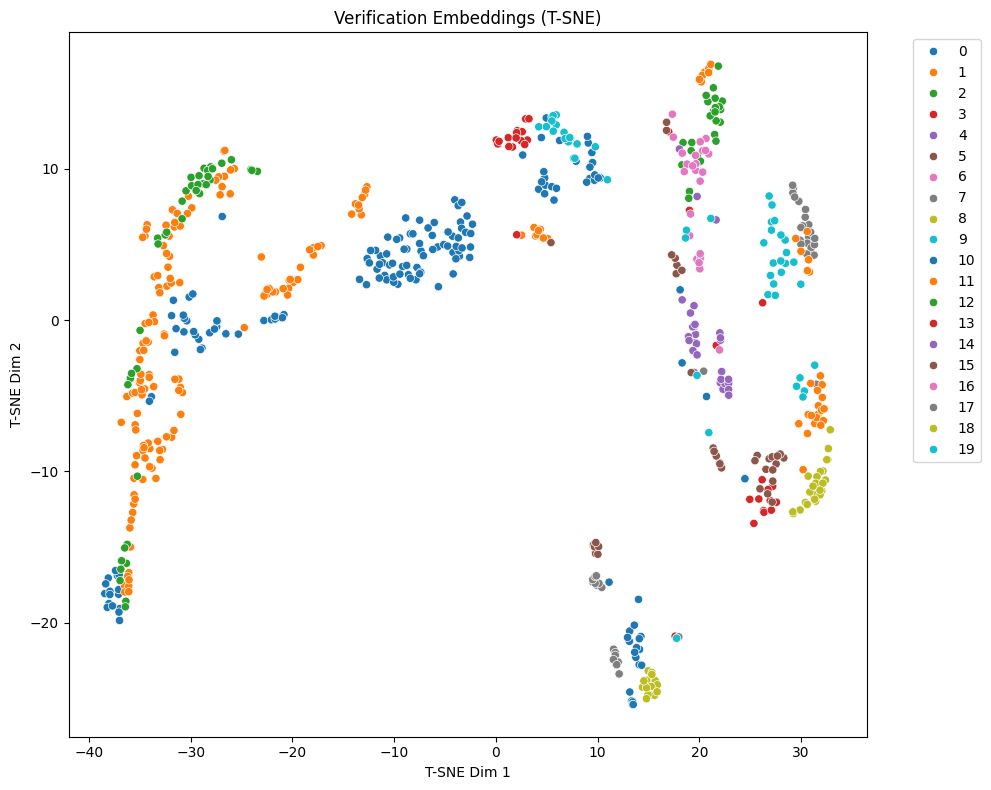

{'eer': 0.3221999999984698, 'auc': 0.74458566}

In [4]:
# --- TASK 5: Blind Segmentation Experiment ---
print("\n=== TASK 5: Blind Segmentation (Long-Term) ===")

blind_params = {
    'mode': 'blind',
    'window_len': 5.0,  
    'stride': 2.0,      
    'bandpass': True,
    'normalize': 'zscore'
}

# Load Long-Term split (Day 1 vs Future) but with Blind Segmentation
loader_blind = load_ecgid_dataset(
    num_beats=1, # Ignored in blind mode
    enrollment_mode='long_term', 
    preprocessing_params=blind_params, 
    cleanup_zip=False
)

x_blind_enr, y_blind_enr = loader_blind.load_session("Session_1")
x_blind_prb, y_blind_prb = loader_blind.load_session("Session_2")

print(f"Blind Data Shapes: Enroll {x_blind_enr.shape}, Probe {x_blind_prb.shape}")

# Run Evaluation
print("\n[Blind] Identification")
run_cross_session_identification(x_blind_enr, y_blind_enr, x_blind_prb, y_blind_prb, DeepECG, epochs=10, device=device)

print("\n[Blind] Verification")
run_cross_session_verification(x_blind_enr, y_blind_enr, x_blind_prb, y_blind_prb, DeepECG, epochs=10, device=device, visualize=True)